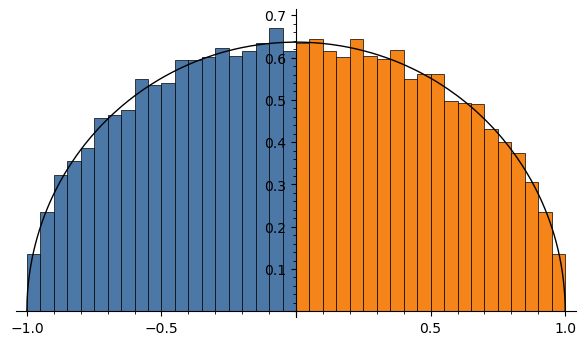

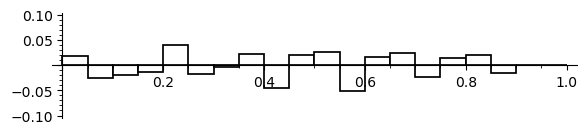

In [1]:
#Plots showing the distribution of H(4n-t^2) for t = m (mod M)
M = 3
m = 1
n = 999983
B = 40 #divide the interval [-1,1] into this number of bins
w = 2/B #width of a bin
#Separate the integers t in the interval [-2*sqrt(n),2*sqrt(n)] into bins:
list_t = [range(ceil(2*sqrt(n)*(-1+i*w)),ceil(2*sqrt(n)*(-1+(i+1)*w))) for i in range(0,B)]
#Select only t = m (mod M):
list_t_mod = [[t for t in b if t%M==m] for b in list_t] #Here b is a range for t
#Sum the class numbers for t in each bin:
list_counts = [sum([pari.qfbhclassno(4*n-t^2) for t in b]) for b in list_t_mod]
#Compute H_{m,M}(n):
total_count = sum(list_counts)
list_rescaled = [float(h/(total_count*w)) for h in list_counts]
#the sum in bin divided by total_count converges to the Sato-Tate measure of the bin

#Bar chart of the scaled number of elliptic curves with trace in each bin:
g = Graphics()
for i, h in enumerate(list_rescaled):
    x0 = -1 + i*w
    if x0>=0:
        g_color='#F58518' #orange
    else:
        g_color='#4C78A8' #blue
    g += polygon([
        (x0, 0),
        (x0 + w, 0),
        (x0 + w, h),
        (x0, h)
    ],rgbcolor=g_color,edgecolor='black',thickness=0.5)
g += plot(2/pi*sqrt(1-x^2),x,-1,1,rgbcolor='black') #add a semicircle
g.set_axes_range(xmin=-1,xmax=1,ymin=0,ymax=0.7)
g.set_aspect_ratio(pi/2) #1 unit on x-axis is pi/2 units on y-axis
show(g)

#Differences positive-negative:
g2 = Graphics()
for i in range(0,floor(B/2)):
    x0 = i*w
    h_pos = list_rescaled[floor(B/2)+i]
    h_neg = list_rescaled[floor(B/2)-i-1]
    g2 += polygon([
        (x0, 0),
        (x0 + w, 0),
        (x0 + w, h_pos-h_neg),
        (x0, h_pos-h_neg)
    ],rgbcolor='white',edgecolor='black',thickness=1.25)
g2.set_axes_range(xmin=0,xmax=1,ymin=-0.1,ymax=0.1)
show(g2)

In [72]:
#Export plots as .png images
g.save('sato-tate-plot-'+str(n)+'.png', dpi=300)
g2.save('sato-tate-plot-bw-'+str(n)+'.png', dpi=300)